## Pregunta 2
**Estudiante:** Jimenez Arias Marilyn Michelle
**Carnet:** U20231085

#### Datos del problema

K₁ ~ Beta(2,4), n=1000
K₂ ~ Uniforme[-6,6], n=1000

Y₁ = 200 + 150K₁ + 50K₂
Y₂ = 200 + 150K₁ + 10K₂(2 + √K₁)

Se ajusta modelo: Y = β₀ + β₁K₁

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

np.random.seed(20231085)

### Definimos la muestra

Datos K1 y K2 (ya le sumamos a 5 para el intervalo)

In [2]:
K1 = np.random.beta(2, 4, 1000)
K2 = np.random.uniform(-6, 6, 1000)

Datos de Y1 y Y2

In [3]:
Y1 = 200 + 150*K1 + 50*K2
Y2 = 200 + 150*K1 + 10*K2*(2 + np.sqrt(K1))

### Regresion de Y1 y Y2

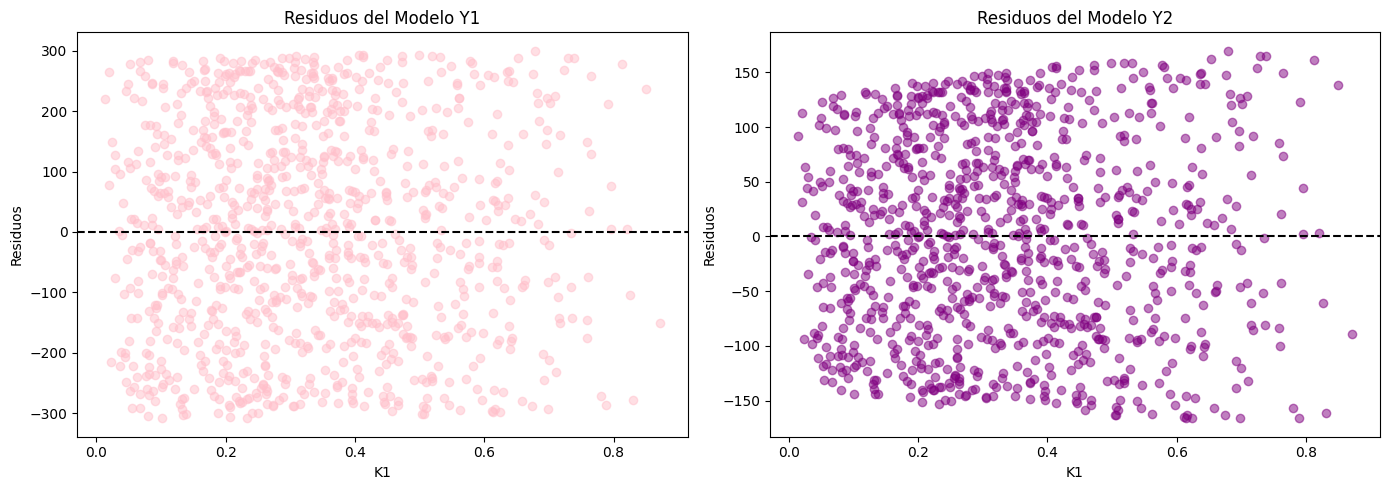

In [6]:
X_sm = sm.add_constant(K1)

modelo_Y1 = sm.OLS(Y1, X_sm).fit()
residuos_Y1 = modelo_Y1.resid

modelo_Y2 = sm.OLS(Y2, X_sm).fit()
residuos_Y2 = modelo_Y2.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(K1, residuos_Y1, alpha=0.5, color='pink')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Residuos del Modelo Y1')
axes[0].set_xlabel('K1')
axes[0].set_ylabel('Residuos')

axes[1].scatter(K1, residuos_Y2, alpha=0.5, color='purple')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Residuos del Modelo Y2')
axes[1].set_xlabel('K1')
axes[1].set_ylabel('Residuos')

plt.tight_layout()
plt.show()

bp_test_Y1 = het_breuschpagan(residuos_Y1, X_sm)
bp_test_Y2 = het_breuschpagan(residuos_Y2, X_sm)

### Realizamos la prueba Breusch-Pagan

In [7]:
print(f"Modelo Y1 - P-valor: {bp_test_Y1[1]:.4e}")
print(f"Modelo Y2 - P-valor: {bp_test_Y2[1]:.4e}")

Modelo Y1 - P-valor: 7.5324e-01
Modelo Y2 - P-valor: 2.3279e-06
